In [5]:
from typing_extensions import Literal
from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langgraph.graph import MessagesState, StateGraph,START,END
from langgraph.types import Command
from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.prebuilt.chat_agent_executor import create_react_agent
from typing import Annotated
from langchain_experimental.utilities import PythonREPL

In [6]:
load_dotenv()

True

In [7]:
openai_model=ChatOpenAI(model="gpt-4o-mini")

In [4]:
openai_model.invoke("hi")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f6834ac66f', 'id': 'chatcmpl-Df4rT92bufjPvZBYLXuhIwAbdH2xt', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e21bd-2a34-72a2-b3b3-ef12a41a2076-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [8]:
def add_numbers(state):
    result = state["num1"] + state["num2"]
    print(f"addition result: {result}")
    return Command(goto="multipley", update={"sum":result})

In [9]:
state={"num1":1, "num2":2}
add_numbers(state)

addition result: 3


Command(update={'sum': 3}, goto='multipley')

In [10]:
@tool
def transfer_to_multiplication_expert():
    """Ask multiplication agent for help"""
    return  

@tool
def transfer_to_addition_expert():
    """Ask addition agent for help"""
    return 


In [11]:
model_with_tool = openai_model.bind_tools([transfer_to_multiplication_expert])

In [13]:
ai_message = model_with_tool.invoke("hi how are you?")
ai_message.tool_calls

[]

In [14]:
ai_message=model_with_tool.invoke("what's (3 + 5) * 12. Provide me the output")
ai_message.tool_calls

[{'name': 'transfer_to_multiplication_expert',
  'args': {},
  'id': 'call_cYCIMNKmunvdZMDCuBaBylDj',
  'type': 'tool_call'}]

In [27]:
def addition_expert(state:MessagesState)-> Command[Literal["multiplication_expert", "__end__"]]:
    
    system_prompt = (
        "You are an addition expert, you can ask the multiplication expert for help with multiplication."
        "Always do your portion of calculation before the handoff."
    )
    
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    
    
    ai_msg = openai_model.bind_tools([transfer_to_multiplication_expert]).invoke(messages)
    
    
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }
        
        return Command(
            goto="multiplication_expert", update={"messages": [ai_msg, tool_msg]}
        )
    return {"messages": [ai_msg]}

In [30]:
def multiplication_expert(state:MessagesState)-> Command[Literal["addition_expert", "__end__"]]:
    
    system_prompt = (
        "You are a multiplication expert, you can ask an addition expert for help with addition. "
        "Always do your portion of calculation before the handoff."
    )
    
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    
    ai_msg = openai_model.bind_tools([transfer_to_addition_expert]).invoke(messages)
    
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }
        return Command(goto="additional_expert", update={"messages": [ai_msg, tool_msg]})
    return {"messages": [ai_msg]}

In [31]:
graph = StateGraph(MessagesState)
graph.add_node("addition_expert", addition_expert)
graph.add_node("multiplication_expert", multiplication_expert)
graph.add_edge(START, "addition_expert")
app = graph.compile()

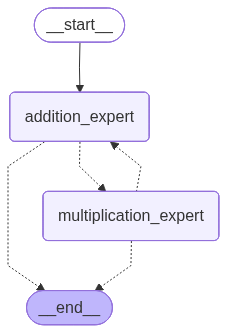

In [32]:
display(Image(app.get_graph().draw_mermaid_png()))

In [33]:
app.invoke({"messages":[("user","what's (3 + 5) * 12. Provide me the output")]})

Task multiplication_expert with path ('__pregel_pull', 'multiplication_expert') wrote to unknown channel branch:to:additional_expert, ignoring it.


{'messages': [HumanMessage(content="what's (3 + 5) * 12. Provide me the output", additional_kwargs={}, response_metadata={}, id='7e0e49f6-d341-44fa-a3f4-374217dcca84'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 86, 'total_tokens': 101, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_e88d325396', 'id': 'chatcmpl-Df5BbiUwvNTiu7VsE7olwp73wtlkS', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e21d0-3918-73f2-97d0-55722b23498e-0', tool_calls=[{'name': 'transfer_to_multiplication_expert', 'args': {}, 'id': 'call_hcI1xaq4BZoDFj0LRPL2HFRL', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input

In [34]:
from langchain_core.messages import convert_to_messages
def pretty_print_messages(update):
    if isinstance(update, tuple):
        ns, update = update
        # skip parent graph updates in the printouts
        if len(ns) == 0:
            return

        graph_id = ns[-1].split(":")[0]
        print(f"Update from subgraph {graph_id}:")
        print("\n")

    for node_name, node_update in update.items():
        print(f"Update from node {node_name}:")
        print("\n")

        for m in convert_to_messages(node_update["messages"]):
            m.pretty_print()
        print("\n")

In [35]:
# Let's run the graph with an expression that requires both addition and multiplication:
for chunk in app.stream(
    {"messages": [("user", "what's (3 + 5) * 12. Provide me the output")]},
):
    print("****chunk...****")
    
    pretty_print_messages(chunk)

****chunk...****
Update from node addition_expert:


================================== Ai Message ==================================
Tool Calls:
  transfer_to_multiplication_expert (call_2qH5OaHm3StojTL8s6ue75BA)
 Call ID: call_2qH5OaHm3StojTL8s6ue75BA
  Args:
================================= Tool Message =================================

Successfully transferred




Task multiplication_expert with path ('__pregel_pull', 'multiplication_expert') wrote to unknown channel branch:to:additional_expert, ignoring it.


****chunk...****
Update from node multiplication_expert:


================================== Ai Message ==================================
Tool Calls:
  transfer_to_addition_expert (call_zA3sP2uVHB6NktNns1LL4sqg)
 Call ID: call_zA3sP2uVHB6NktNns1LL4sqg
  Args:
================================= Tool Message =================================

Successfully transferred




In [36]:
@tool
def transfer_to_travel_advisor():
    """Ask travel advisor for help."""
    return
@tool
def transfer_to_hotel_advisor():
    """Ask hotel advisor for help."""
    return

In [37]:
def travel_advisor(state: MessagesState) -> Command[Literal["hotel_advisor", "__end__"]]:
    system_prompt = (
        "You are a general travel expert that can recommend travel destinations (e.g. countries, cities, etc). "
        "If you need hotel recommendations, ask 'hotel_advisor' for help."
    )
    
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    
    ai_msg = openai_model.bind_tools([transfer_to_hotel_advisor]).invoke(messages)
    
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }
        
        return Command(goto="hotel_advisor", update={"messages": [ai_msg, tool_msg]})
    
    return {"messages": [ai_msg]}

In [38]:
def hotel_advisor(state: MessagesState) -> Command[Literal["travel_advisor", "__end__"]]:
    system_prompt = (
        "You are a hotel expert that can provide hotel recommendations for a given destination. "
        "If you need help picking travel destinations, ask 'travel_advisor' for help."
    )
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    ai_msg = openai_model.bind_tools([transfer_to_travel_advisor]).invoke(messages)
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }
        return Command(goto="travel_advisor", update={"messages": [ai_msg, tool_msg]})
    return {"messages": [ai_msg]}

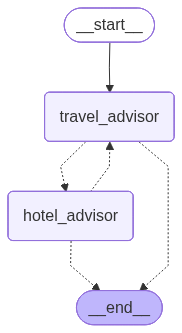

In [39]:
graph_builder = StateGraph(MessagesState)
graph_builder.add_node("travel_advisor", travel_advisor)
graph_builder.add_node("hotel_advisor", hotel_advisor)
# we'll always start with a general travel advisor
graph_builder.add_edge(START, "travel_advisor")
app = graph_builder.compile()
display(Image(app.get_graph().draw_mermaid_png()))

In [40]:
app.invoke({"messages":[("user","I am planning a trip to the California in the USA from Mumbai. Can you guide me on travel options and suggest the best hotel?")]})

{'messages': [HumanMessage(content='I am planning a trip to the California in the USA from Mumbai. Can you guide me on travel options and suggest the best hotel?', additional_kwargs={}, response_metadata={}, id='69cd80b0-0ba4-441a-a2c6-f479cf23ff95'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 104, 'total_tokens': 136, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f6834ac66f', 'id': 'chatcmpl-Df5Ej9dScQbwFX5y93e779B0fdX9c', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e21d3-241d-7c52-99ec-a28bcc7a10a5-0', tool_calls=[{'name': 'transfer_to_hotel_advisor', 'args': {}, 'id': 'call_D5VYOJuaXpxIWtX0yQQ

In [43]:
for chunk in app.stream(
    {"messages": [("user", "I am planning a trip to the California in the USA from Mumbai. Can you guide me on travel options and suggest the best hotel?")]},
):
    print("****chunk****")
    
    pretty_print_messages(chunk)

****chunk****
Update from node travel_advisor:


================================== Ai Message ==================================
Tool Calls:
  transfer_to_hotel_advisor (call_yDN51fYAvlotnl9HK6bxkNlP)
 Call ID: call_yDN51fYAvlotnl9HK6bxkNlP
  Args:
================================= Tool Message =================================

Successfully transferred


****chunk****
Update from node hotel_advisor:


================================== Ai Message ==================================

I can help you with hotel recommendations, but for travel options from Mumbai to California, please consult a travel advisor. Would you like me to assist you with hotel suggestions in California? If so, which city or area are you planning to stay in?




In [44]:
for chunk in app.stream(
    {"messages": [("user", "What are the best flight options from Mumbai to California, and can you recommend top hotels for a comfortable and convenient stay?")]},
):
    print("****chunk****")
    
    pretty_print_messages(chunk)

****chunk****
Update from node travel_advisor:


================================== Ai Message ==================================
Tool Calls:
  transfer_to_hotel_advisor (call_03bxqpP7dujGj4ZpQZS74psc)
 Call ID: call_03bxqpP7dujGj4ZpQZS74psc
  Args:
================================= Tool Message =================================

Successfully transferred


****chunk****
Update from node hotel_advisor:


================================== Ai Message ==================================

I can help you with hotel recommendations for California. However, for flight options from Mumbai to California, you may want to check travel booking websites or consult airlines directly for the best deals and schedules.

Please let me know which city in California you're interested in, and I can recommend some top hotels for a comfortable and convenient stay.




In [46]:
for chunk in app.stream(
    {"messages": [("user", "I am interested in new York?")]},
):
    print("****chunk****")
    
    pretty_print_messages(chunk)

****chunk****
Update from node travel_advisor:


================================== Ai Message ==================================

New York City is a vibrant and diverse destination with something for everyone. Here are some highlights and recommendations for your visit:

1. **Iconic Landmarks**: Visit famous sites like the Statue of Liberty, Times Square, Central Park, and the Empire State Building.

2. **Museums and Culture**: Explore world-class museums such as the Metropolitan Museum of Art, the Museum of Modern Art (MoMA), and the American Museum of Natural History.

3. **Broadway Shows**: Experience the excitement of a Broadway show; there is always a variety of performances to choose from.

4. **Diverse Neighborhoods**: Wander through different neighborhoods like Chinatown, Little Italy, Harlem, and Williamsburg to experience varied cultures and cuisines.

5. **Food Scene**: Try classic New York foods such as bagels, pizza, and deli sandwiches. Don’t miss the food markets and tr